# Data Download and Preprocessing

In this notebook, we will download the vector data and contextual layers needed for this project. 
See this spreadsheet for the list of data sources and the corresponding links: [Data Sources](
https://docs.google.com/spreadsheets/d/1XSG0xyoWcLVuGSY2-Mrfalyf6tN--PPOkQWVxDr6XfM/edit?usp=sharing
).
We will also preprocess the data to make it ready for analysis.

## Table of Contents
### [Data Download](#data-download)
- **[HydroBASINS](#hydro)**
- **[Country Boundaries (OSM)](#country-boundaries)**

## Setup

### Library import


In [81]:
import os
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
import pycountry
import requests

### Utils

In [3]:
def download_and_unzip(url, directory):
    """
    Download a zip file from a URL and unzip it to a directory.
    Returns the path to the directory containing the unzipped files.
    """
    # Download the file
    response = requests.get(url, timeout=10)
    zip_file_name = os.path.basename(url)
    zip_file_path = os.path.join(directory, zip_file_name)
    with open(zip_file_path, "wb") as file:
        file.write(response.content)

    # Create a new directory for the unzipped files
    unzip_dir = os.path.join(directory, os.path.splitext(zip_file_name)[0])
    os.makedirs(unzip_dir, exist_ok=True)

    # Unzip the file
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall(unzip_dir)

    # Remove the zip file
    os.remove(zip_file_path)

    return unzip_dir


def unzip_file(zip_file_path):
    """
    Unzip a file to a directory.

    Parameters
    ----------
    zip_file_path : str
        The path to the zip file to unzip.
    """
    # Create a new directory for the unzipped files
    unzip_dir = os.path.splitext(zip_file_path)[0]
    os.makedirs(unzip_dir, exist_ok=True)

    # Unzip the file
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall(unzip_dir)

In [4]:
def get_multiple_countries_osmx(country_list):
    """
    Get multiple countries using OSMnx
    """
    all_countries = []

    for country in country_list:
        try:
            country_gdf = ox.geocode_to_gdf(country, which_result=1)
            country_gdf["country_name"] = country
            all_countries.append(country_gdf)
            print(f"Successfully got data for {country}")
        except Exception as e:
            print(f"Failed to get data for {country}: {e}")

    if all_countries:
        combined_gdf = pd.concat(all_countries, ignore_index=True)
        return combined_gdf
    else:
        return None

In [ ]:
def name_to_iso3(name):
    """
    Convert a country name to its ISO 3166-1 alpha-3 code.
    """
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        print(f"Country name '{name}' not found in pycountry.")
        return None

<a id='hydro'></a>
### HydroBASINS ([source](https://www.hydrosheds.org/products/hydrobasins))

**License**

The HydroBASINS database is freely available for scientific, educational and commercial use. The data are distributed under the same license agreement as the HydroSHEDS core products, which is included in the [HydroSHEDS Technical Documentation](https://data.hydrosheds.org/file/technical-documentation/HydroSHEDS_TechDoc_v1_4.pdf). For all regulations regarding license grants, copyright, redistribution restrictions, required attributions, disclaimer of warranty, indemnification, liability, and waiver of damages, please refer to the license agreement.

By downloading and using the data the user agrees to the terms and conditions of this license.

**References**
Lehner, B., Grill G. (2013). Global river hydrography and network routing: baseline data and new approaches to study the world’s large river systems. Hydrological Processes, 27(15): 2171–2186. https://doi.org/10.1002/hyp.9740

**Download data**

From FAO Map Catalog: [Hydrological basins in Africa](https://data.apps.fao.org/map/catalog/srv/eng/catalog.search#/metadata/e54e2014-d23b-402b-8e73-c827628d17f4)

In [5]:
url = "https://storage.googleapis.com/fao-maps-catalog-data/geonetwork/aquamaps/hydrobasins_africa.zip"
directory = "../data/raw/"
dir_path = download_and_unzip(url, directory)
print("Downloaded and unzipped to", dir_path)

Downloaded and unzipped to ../data/raw/hydrobasins_africa


**Read data**

In [45]:
gdf = gpd.read_file("../data/raw/hydrobasins_africa/hydrobasins_africa.shp")
gdf.sort_values(by="MAJ_NAME", ascending=True, inplace=True)
gdf.columns = gdf.columns.str.lower()
gdf.drop(columns=["to_bas", "legend"], inplace=True)
gdf_sub_bas = gdf.dissolve(by="sub_bas", as_index=False)
gdf_sub_bas["level"] = 2
cols = [c for c in gdf_sub_bas.columns if c != "geometry"] + ["geometry"]
gdf_sub_bas = gdf_sub_bas[cols]
gdf_sub_bas.head()

,sub_bas,maj_bas,sub_name,maj_name,sub_area,maj_area,level,geometry
0,10978,7001,Ferlo,Senegal,45131,477345,2,"POLYGON ((-15.5875 16.475, -15.5875 16.4625, -..."
1,10981,7001,Senegal Delta,Senegal,5341,477345,2,"POLYGON ((-16.50417 15.9875, -16.50417 15.9916..."
2,10982,7001,Senegal 1,Senegal,30152,477345,2,"POLYGON ((-13.525 17.48333, -13.525 17.47917, ..."
3,10983,7001,Senegal 2,Senegal,43436,477345,2,"POLYGON ((-12.00833 17.47917, -12.00833 17.475..."
4,10984,7001,Karakoro,Senegal,47574,477345,2,"POLYGON ((-10.62917 18.45833, -10.62917 18.454..."


**Data processing**

create Major River Basins geometries by dissolving sub-basins.
```python

In [47]:
gdf_maj_bas = gdf_sub_bas[["maj_bas", "maj_name", "maj_area", "geometry"]].copy()
gdf_maj_bas = gdf_maj_bas.dissolve(by="maj_bas", as_index=False)
gdf_maj_bas["level"] = 1
cols = [c for c in gdf_maj_bas.columns if c != "geometry"] + ["geometry"]
gdf_maj_bas = gdf_maj_bas[cols]
gdf_maj_bas.head()

,maj_bas,maj_name,maj_area,level,geometry
0,7001,Senegal,477345,1,"MULTIPOLYGON (((-11.2625 11.69583, -11.26667 1..."
1,7002,Niger,2136941,1,"MULTIPOLYGON (((-5.35417 11.00417, -5.35 11.00..."
2,7003,Nile,3074955,1,"MULTIPOLYGON (((32.18333 -2.975, 32.18333 -2.9..."
3,7004,Shebelli - Juba,796599,1,"POLYGON ((42.27083 -0.2125, 42.27083 -0.21667,..."
4,7005,Congo,3696670,1,"MULTIPOLYGON (((19 -11.5875, 19 -11.59167, 18...."


Merge the sub-basins into major basins

In [48]:
gdf = pd.concat([gdf_maj_bas, gdf_sub_bas], ignore_index=True)
gdf.sort_values(by=["maj_name", "level"], ascending=True, inplace=True)
cols = [c for c in gdf.columns if c != "geometry"] + ["geometry"]
gdf = gdf[cols]
gdf.head()

,maj_bas,maj_name,maj_area,level,sub_bas,sub_name,sub_area,geometry
15,7018,"Africa, East Central Coast",1041192,1,NaN,NaN,NaN,"MULTIPOLYGON (((38.87083 -17.22917, 38.8875 -1..."
422,7018,"Africa, East Central Coast",1041192,2,180371.0,Kenyan north east coast,49241.0,"MULTIPOLYGON (((40.8375 -2.43333, 40.8375 -2.4..."
423,7018,"Africa, East Central Coast",1041192,2,180372.0,Tana,96296.0,"POLYGON ((38.28333 0.4875, 38.28333 0.48333, 3..."
424,7018,"Africa, East Central Coast",1041192,2,180374.0,Galana,46624.0,"POLYGON ((36.59167 -0.84167, 36.59167 -0.85, 3..."
425,7018,"Africa, East Central Coast",1041192,2,180376.0,Pangani,51206.0,"POLYGON ((37.2125 -3.04167, 37.2125 -3.05, 37...."


Filter the sub-basins to only include those that are part of Sahel region

In [49]:
sahel = gpd.read_file("../data/raw/Sahel-zone - extended - dissolved.gpkg")

In [54]:
hydro = gdf[gdf.geometry.intersects(sahel.unary_union)]
hydro.reset_index(drop=True, inplace=True)
hydro.head()

/tmp/ipykernel_144059/2112725600.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro = gdf[gdf.geometry.intersects(sahel.unary_union)]


,maj_bas,maj_name,maj_area,level,sub_bas,sub_name,sub_area,geometry
0,7018,"Africa, East Central Coast",1041192,1,NaN,NaN,NaN,"MULTIPOLYGON (((38.87083 -17.22917, 38.8875 -1..."
1,7018,"Africa, East Central Coast",1041192,2,180371.0,Kenyan north east coast,49241.0,"MULTIPOLYGON (((40.8375 -2.43333, 40.8375 -2.4..."
2,7018,"Africa, East Central Coast",1041192,2,180372.0,Tana,96296.0,"POLYGON ((38.28333 0.4875, 38.28333 0.48333, 3..."
3,7018,"Africa, East Central Coast",1041192,2,180374.0,Galana,46624.0,"POLYGON ((36.59167 -0.84167, 36.59167 -0.85, 3..."
4,7018,"Africa, East Central Coast",1041192,2,180376.0,Pangani,51206.0,"POLYGON ((37.2125 -3.04167, 37.2125 -3.05, 37...."


<Axes: >

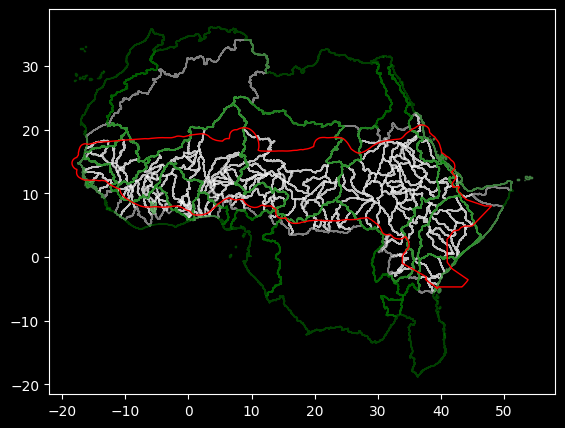

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))

hydro_1 = hydro[hydro["level"] == 1]
hydro_2 = hydro[hydro["level"] == 2]

hydro_2.plot(ax=ax, color="none", edgecolor="white", alpha=0.5)
hydro_1.plot(ax=ax, color="none", edgecolor="green", alpha=0.5)
sahel.plot(ax=ax, color="none", edgecolor="red")

**Save data**

In [56]:
hydro.to_file("../data/processed/hydrobasins_sahel.geojson", driver="GeoJSON")

<a id='country-boundaries'></a>
### Country Boundaries (OSM) ([source](https://www.hydrosheds.org/products/hydrobasins))


**Read data**

In [83]:
countries_to_get = [
    "Senegal",
    "Mauritania",
    "Mali",
    "Burkina Faso",
    "Niger",
    "Chad",
    "Sudan",
    "Nigeria",
    "Eritrea",
    "Cameroon",
    "The Gambia",
    "Guinea",
    "South Sudan",
    "Ethiopia",
    "Kenya",
    "Côte d'Ivoire",
    "Ghana",
    "Togo",
    "Benin",
    "Guinea-Bissau",
    "Central African Republic",
    "Uganda",
]

countries_gdf = get_multiple_countries_osmx(countries_to_get)

Successfully got data for Senegal
Successfully got data for Mauritania
Successfully got data for Mali
Successfully got data for Burkina Faso
Successfully got data for Niger
Successfully got data for Chad
Successfully got data for Sudan
Successfully got data for Nigeria
Successfully got data for Eritrea
Successfully got data for Cameroon
Successfully got data for The Gambia
Successfully got data for Guinea
Successfully got data for South Sudan
Successfully got data for Ethiopia
Successfully got data for Kenya
Successfully got data for Côte d'Ivoire
Successfully got data for Ghana
Successfully got data for Togo
Successfully got data for Benin
Successfully got data for Guinea-Bissau
Successfully got data for Central African Republic
Successfully got data for Uganda


**Data processing**

In [84]:
# Create "bbox" column
countries_gdf["bbox"] = countries_gdf.apply(
    lambda r: {"bbox": [r["bbox_west"], r["bbox_south"], r["bbox_east"], r["bbox_north"]]}, axis=1
)

countries_gdf = countries_gdf.drop(
    columns=[
        "bbox_west",
        "bbox_south",
        "bbox_east",
        "bbox_north",
        "place_id",
        "osm_type",
        "osm_id",
        "lat",
        "lon",
        "class",
        "type",
        "place_rank",
        "importance",
        "addresstype",
        "display_name",
        "country_name",
    ]
)

# Add ISO3 codes
countries_gdf["ISO3"] = countries_gdf["name"].apply(name_to_iso3)

# Reorder columns to have 'geometry' at the end
cols = [c for c in countries_gdf.columns if c != "geometry"] + ["geometry"]
countries_gdf = countries_gdf[cols]

countries_gdf.head()

,name,bbox,ISO3,geometry
0,Senegal,"{'bbox': [-17.7498686, 12.2402664, -11.3459503...",SEN,"POLYGON ((-17.74987 14.74329, -17.74984 14.741..."
1,Mauritania,"{'bbox': [-17.2380959, 14.7209909, -4.8333344,...",MRT,"POLYGON ((-17.2381 20.66622, -17.23676 20.6625..."
2,Mali,"{'bbox': [-12.2402835, 10.147811, 4.2673828, 2...",MLI,"POLYGON ((-12.24028 14.76472, -12.23971 14.762..."
3,Burkina Faso,"{'bbox': [-5.513207, 9.4104718, 2.4089717, 15....",BFA,"POLYGON ((-5.51321 10.43079, -5.51319 10.43066..."
4,Niger,"{'bbox': [0.1689653, 11.6936071, 15.996667, 23...",NER,"POLYGON ((0.16897 14.52207, 0.17333 14.50556, ..."


<Axes: >

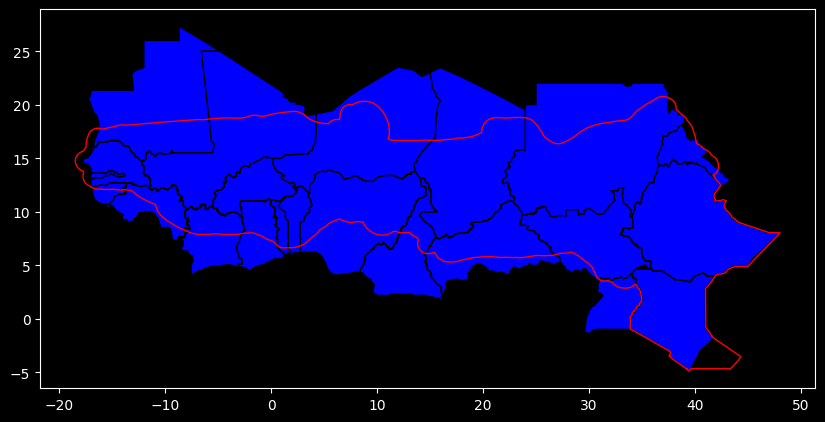

In [85]:
fig, ax = plt.subplots(figsize=(10, 5))

countries_gdf.plot(ax=ax, color="blue", edgecolor="black")
sahel.plot(ax=ax, color="none", edgecolor="red")

**Save data**

In [86]:
countries_gdf.to_file("../data/processed/countries_sahel.geojson", driver="GeoJSON")